In [1]:
%matplotlib inline
import os
import sys
from os.path import join as pjoin
from tifffile import imread, imwrite, TiffFile
import numpy as np
import shutil
import matplotlib.pyplot as plt
from glob import glob
import pandas as pd
import cv2
from tqdm import tqdm
import subprocess
from scipy.ndimage import gaussian_filter,median_filter
from scipy.interpolate import interp1d
from scipy.signal import detrend, butter, filtfilt

project_root = '/home/lsh/WF_GoNogo'
if project_root not in sys.path:
    sys.path.append(project_root)
from utils.wfield_utils import *

In [2]:
config_path = "/home/lsh/WF_GoNogo/config/A299_config.yaml"

Processing session: 20260313
Raw path: /home/lsh/Data_attention/Transfer learning/LinShu/DATA_linshu/000 widefield/A299/20260313
Experiments found: ['20260313-160427']
INTERACTIVE MASK GENERATION
Loading preview stacks (600 frames)...


Loading 470nm: 100%|██████████| 600/600 [00:01<00:00, 341.78it/s]


Preview stack shape: (600, 512, 512)

🎨 Launching interactive mask tool...
   Adjust parameters and click 'Save Mask' when ready.



✅ Interactive contour tool loaded!
   Adjust parameters or draw exclusion circles, then Save.
all done


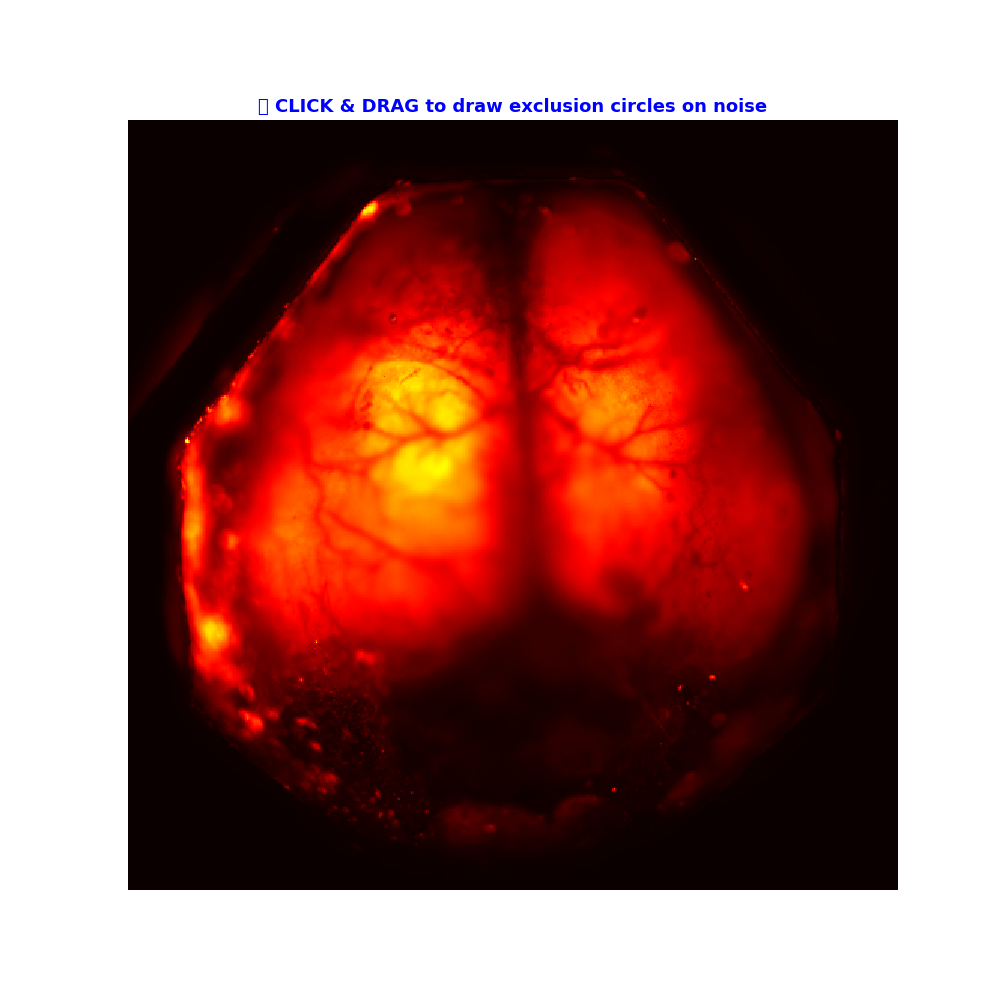

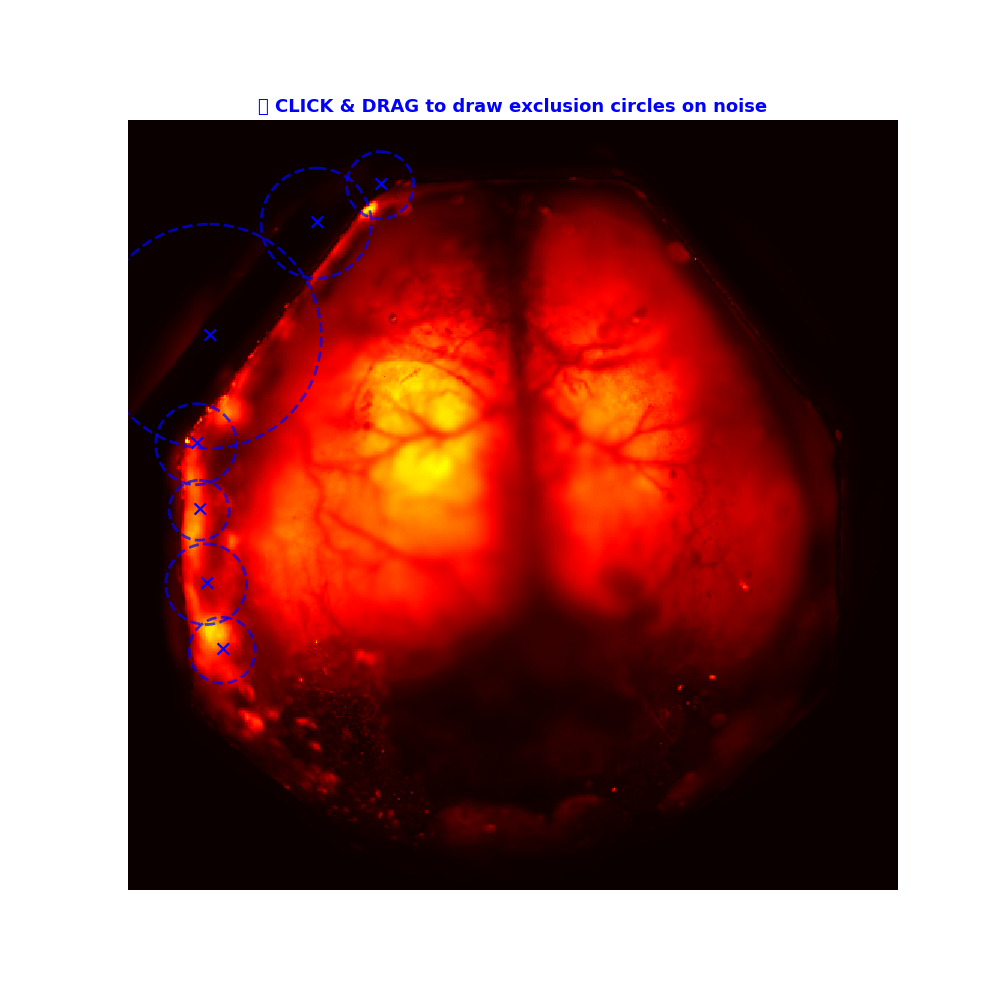

In [ ]:
mask_mice(config_path)

In [12]:
import numpy as np
import imageio.v2 as imageio
from pathlib import Path

# input path
mask_path = Path("/home/lsh/Data_attention/Transfer learning/LinShu/DATA_linshu/000 widefield/A269/retino/process/mask.tif")

# output path
save_path = Path("/home/lsh/Data_attention/Transfer learning/LinShu/DATA_linshu/000 widefield/A269/retino/QualityControl/brain_mask.npy")

# make sure folder exists
save_path.parent.mkdir(parents=True, exist_ok=True)

# load mask
mask = imageio.imread(mask_path)
mask = (mask > 0).astype(np.uint8)

# save
np.save(save_path, mask)

print("Saved to:", save_path)


Saved to: /home/lsh/Data_attention/Transfer learning/LinShu/DATA_linshu/000 widefield/A269/retino/QualityControl/brain_mask.npy


In [12]:
preprocess_mice(config_path)

Processing session: 20260313
Raw path: /home/lsh/Data_attention/Transfer learning/LinShu/DATA_linshu/000 widefield/A299/20260313
Experiments found: ['20260313-160427']
common_idx：22589 (405=22592, 470=22595)
405 missing 6 frames: [np.int64(1945), np.int64(10025), np.int64(11875), np.int64(14025), np.int64(15461), np.int64(16113)]
470 missing 3 frames: [np.int64(1003), np.int64(17810), np.int64(22172)]


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (22589,) + inhomogeneous part.

In [7]:
# batch_widefield_preproc_with_outlier.py
import os
from os.path import join as pjoin
from glob import glob
import numpy as np
from tifffile import imread, imwrite
import matplotlib.pyplot as plt
import yaml
import time
import re

# ------------------------------
# Funtions
# ------------------------------
def load_config(config_path):
    """load the YAML config"""
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    return config

def filename2int(filename):
    nums = re.findall(r'\d+', filename)
    return int(nums[-1]) if nums else -1

# ------------------------------
# Step 1: organize tiffes
# ------------------------------
# def organize_tif(folder_path, processPath):
#     folder_name = os.path.basename(folder_path)
#     tif_path = folder_path + '.tif'
#     if os.path.exists(tif_path):
#         print(f'importing {tif_path}')
#         image_stack = imread(tif_path)
#         print(f'finish importing {tif_path}')
#     else:
#         image_path_ls = glob(os.path.join(folder_path, '*.tif'))
#         image_path_ls = sorted(image_path_ls, key=filename2int)
#         image_stack = [imread(tiff) for tiff in image_path_ls]
#     mean_values = [np.mean(frame) for frame in image_stack]
#     output_value = os.path.join(processPath, folder_name + "-Values.csv")
#     np.savetxt(output_value, mean_values, delimiter=",")
#     return np.array(image_stack)



def merge_two_channels(rawPath, processPath, timePath, experiment):
    """Merge two channels (405 & 470) after dropping unmatched frames."""
    os.makedirs(os.path.join(processPath, experiment + "-wfield"), exist_ok=True)
    mergePath = os.path.join(processPath, experiment + "-wfield")
    merge_file = os.path.join(mergePath, experiment + "-merged.tif")

    if os.path.exists(merge_file):
        print(f"Merged {experiment} already exists")
        return merge_file

    folder_405 = os.path.join(rawPath, experiment + "-405")
    folder_470 = os.path.join(rawPath, experiment + "-470")

    paths_405 = sorted(glob(os.path.join(folder_405, "*.tif")), key=filename2int)
    paths_470 = sorted(glob(os.path.join(folder_470, "*.tif")), key=filename2int)
    idx_405 = np.array([filename2int(p) for p in paths_405])
    idx_470 = np.array([filename2int(p) for p in paths_470])

    timestamps_470 = np.load(pjoin(timePath, "widefield_timestamps_blue.npy"))
    timestamps_405 = np.load(pjoin(timePath, "widefield_timestamps_violet.npy"))

    common_idx = np.intersect1d(idx_405, idx_470)

    print(f"common_idx：{len(common_idx)} (405={len(idx_405)}, 470={len(idx_470)})")
    missing_405 = set(idx_470) - set(idx_405)
    missing_470 = set(idx_405) - set(idx_470)
    print(f"405 missing {len(missing_405)} frames: {sorted(list(missing_405))[:10]}")
    print(f"470 missing {len(missing_470)} frames: {sorted(list(missing_470))[:10]}")

    if len(common_idx) == 0:
        raise ValueError("No overlapping frames between 405 and 470 channels!")

    valid_405 = [os.path.join(folder_405, f"{i}.tif") for i in common_idx if os.path.exists(os.path.join(folder_405, f"{i}.tif"))]
    valid_470 = [os.path.join(folder_470, f"{i}.tif") for i in common_idx if os.path.exists(os.path.join(folder_470, f"{i}.tif"))]
    
    idx2time_470 = dict(zip(idx_470, timestamps_470))
    idx2time_405 = dict(zip(idx_405, timestamps_405))
    time_470 = [idx2time_470[i] for i in common_idx if i in idx2time_470]
    time_405 = [idx2time_405[i] for i in common_idx if i in idx2time_405]


    # tif_405 = np.array([imread(p) for p in valid_405])
    # tif_470 = np.array([imread(p) for p in valid_470])
    tif_405 = []
    for p in valid_405:
        try:
            tif_405.append(imread(p))
        except Exception as e:
            print("\n❌ Bad TIFF file (405):")
            print(p)
            print("Reason:", e)
            raise
    tif_405 = np.array(tif_405)

    tif_470 = []
    for p in valid_470:
        try:
            tif_470.append(imread(p))
        except Exception as e:
            print("\n❌ Bad TIFF file (470):")
            print(p)
            print("Reason:", e)
            raise
    tif_470 = np.array(tif_470)


    merged_tif = np.stack([tif_470, tif_405], axis=1)  # shape = (frames, 2, H, W)
    imwrite(merge_file, merged_tif, imagej=True, bigtiff=True)

    # Save mean values for outlier detection
    mean_470 = [np.mean(frame) for frame in tif_470]
    mean_405 = [np.mean(frame) for frame in tif_405]
    np.savetxt(os.path.join(processPath, f"{experiment}-470-Values.csv"), mean_470, delimiter=",")
    np.savetxt(os.path.join(processPath, f"{experiment}-405-Values.csv"), mean_405, delimiter=",")
    np.save(os.path.join(timePath, "widefield_timestamps_blue.npy"), np.array(time_470))
    np.save(os.path.join(timePath, "widefield_timestamps_violet.npy"),np.array(time_405))

    print(f"Merge completed: {merge_file}")
    print(f"Final frames: {merged_tif.shape[0]}")

    return merge_file


# ------------------------------
# Step 2: Outlier dection and correction
# ------------------------------
def detect_outlier(mean_values, std_thr=5, qc_path=None, plot=True):
    def find_continuous_outliers(outlier_idx):
        if len(outlier_idx) == 0:
            return []
        segments, start = [], outlier_idx[0]
        for i in range(1, len(outlier_idx)):
            if outlier_idx[i] != outlier_idx[i-1] + 1:
                segments.append((start, outlier_idx[i-1]))
                start = outlier_idx[i]
        segments.append((start, outlier_idx[-1]))
        return segments

    outlier_470 = mean_values[:,0] < mean_values[:,0].mean() - std_thr*mean_values[:,0].std()
    outlier_405 = (mean_values[:,1] < mean_values[:,1].mean() - std_thr*mean_values[:,1].std()) | \
                  (mean_values[:,1] > mean_values[:,1].mean() + std_thr*mean_values[:,1].std())
    outlier_470_segments = find_continuous_outliers(np.where(outlier_470)[0])
    outlier_405_segments = find_continuous_outliers(np.where(outlier_405)[0])

    if plot:
        fig, ax = plt.subplots(figsize=(20,5))
        ax.plot(mean_values[:,0], label='470', color='g')
        ax.plot(mean_values[:,1], label='405', color='purple')
        for s,e in outlier_470_segments:
            ax.plot(np.arange(s,e+1), mean_values[s:e+1,0], 'ko', fillstyle='none')
        for s,e in outlier_405_segments:
            ax.plot(np.arange(s,e+1), mean_values[s:e+1,1], 'ro', fillstyle='none')
        ax.legend()
        plt.title('Raw Mean Values with Outliers')
        
    if qc_path is not None:
            os.makedirs(qc_path, exist_ok=True)
            save_path = os.path.join(qc_path, f"outlier_detection.png")
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            plt.close(fig) 
            print(f"Outlier dection plot saved to: {save_path}")

    return outlier_470_segments, outlier_405_segments

def correct_lum_outlier(merged_tif, outlier_index_470, outlier_index_405, qc_path, plot=True):
    """Detect and correct luminance outliers, then save corrected data as .bin."""
    data = imread(merged_tif)  # (nframes, nchannels, H, W)
    n_frames, n_channels, H, W = data.shape
    print("Merged frames:", n_frames)

    # --- Outlier correction ---
    for start, end in outlier_index_470:
        data[start:end+1, 0, :, :] = 0.5 * data[start-1, 0, :, :] + 0.5 * data[end+1, 0, :, :]
    for start, end in outlier_index_405:
        data[start:end+1, 1, :, :] = 0.5 * data[start-1, 1, :, :] + 0.5 * data[end+1, 1, :, :]

    # --- Convert to uint16 if not already ---
    if data.dtype != np.uint16:
        data = np.clip(data, 0, np.iinfo(np.uint16).max).astype(np.uint16)

    # --- Define .bin filename ---
    corrected_file = os.path.join(
        os.path.dirname(merged_tif),
        f"{n_frames}_{n_channels}_{H}_{W}_uint16.bin"
    )

    # --- Save as binary file ---
    data.tofile(corrected_file)
    print(f"Corrected .bin file saved: {corrected_file}")

    # --- Optional: Plot and save QC ---
    if plot:
        mean_values_corrected = np.stack([
            data[:, 0].mean(axis=(1, 2)),
            data[:, 1].mean(axis=(1, 2))
        ], axis=1)
        fig, ax = plt.subplots(figsize=(20, 5))
        ax.plot(mean_values_corrected[:, 0], label='470', color='g')
        ax.plot(mean_values_corrected[:, 1], label='405', color='purple')
        ax.legend()
        plt.title('Corrected Mean Values')

        if qc_path is not None:
            os.makedirs(qc_path, exist_ok=True)
            save_path = os.path.join(qc_path, "outlier_correction.png")
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            plt.close(fig)
            print(f"Outlier correction plot saved to: {save_path}")

    return corrected_file


# ------------------------------
# Step 3: Masking
# ------------------------------

# import numpy as np
# import cv2, os
# from glob import glob
# from tifffile import imread, imwrite
# from skimage import measure
# import matplotlib.pyplot as plt
# from tqdm import tqdm
# from os.path import join as pjoin

# def show_images(images, titles=None, cmap='hot', colorbar=True, qc_path=None):
#     n = len(images)
#     fig, axes = plt.subplots(1, n, figsize=(12, 4), constrained_layout=True)
#     if n == 1:
#         axes = [axes]
#     ims = []
#     for i, img in enumerate(images):
#         im = axes[i].imshow(img, cmap=cmap, aspect='equal')
#         ims.append(im)
#         if titles:
#             axes[i].set_title(titles[i])
#         axes[i].axis('off')
#     if colorbar:
#         fig.colorbar(ims[-1], ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

#     if qc_path is not None:
#         plt.savefig(qc_path, dpi=300, bbox_inches="tight")
#         plt.close(fig)
#         print(f"Preview figure saved: {qc_path}")
#     else:
#         plt.show()

# import os
# import numpy as np
# import cv2
# from glob import glob
# from os.path import join as pjoin
# from skimage import measure
# from tifffile import imread
# import matplotlib.pyplot as plt

# def show_images(images, titles=None, colorbar=False, qc_path=None):
#     """Utility function for visualization."""
#     n = len(images)
#     fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
#     if n == 1:
#         axes = [axes]
#     for i, (ax, img) in enumerate(zip(axes, images)):
#         im = ax.imshow(img, cmap='hot')
#         if titles:
#             ax.set_title(titles[i])
#         ax.axis('off')
#         if colorbar:
#             plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
#     if qc_path:
#         plt.savefig(qc_path, dpi=300, bbox_inches="tight")
#         plt.close(fig)
#     else:
#         plt.show()


# def generate_mask(rawPath, processPath, experiment, std_level=150, n_preview=600, plot_test=False, qc_path=None):
#     """
#     Generate a brain mask based on std image difference (470 vs 405 nm).
#     Removes signals outside skull area, no cropping performed.
#     """
#     # Load tiff preview
#     tiff_list_470 = glob(pjoin(rawPath, experiment + '*-470/*.tif'))[:n_preview]
#     tiff_list_405 = glob(pjoin(rawPath, experiment + '*-405/*.tif'))[:n_preview]

#     preview_stack_470 = np.array([imread(t) for t in tiff_list_470])
#     preview_stack_405 = np.array([imread(t) for t in tiff_list_405])

#     preview_std_470 = np.std(preview_stack_470, axis=0)
#     preview_std_405 = np.std(preview_stack_405, axis=0)

#     # QC visualization of std maps
#     if plot_test:
#         images = [preview_std_470, preview_std_405, preview_std_470 - preview_std_405]
#         titles = ['Std of 470 nm', 'Std of 405 nm', 'Difference (470 - 405)']
#         save_path = os.path.join(qc_path, f"std_preview.png") if qc_path else None
#         show_images(images, titles=titles, colorbar=True, qc_path=save_path)

#     # Find contour
#     contour = measure.find_contours(image=preview_std_470, level=std_level)
#     contour_len = [len(_c) for _c in contour]
#     contour_max = contour[np.argmax(contour_len)]

#     # Generate mask
#     mask = np.zeros_like(preview_std_470)
#     mask_edge = np.flip(contour_max, axis=1).astype(int)
#     mask = cv2.fillPoly(mask, [mask_edge], 1).astype(bool)

#     # Visualization
#     fig, ax = plt.subplots(1, 3, figsize=(15, 5))
#     ax[0].imshow(preview_std_470, cmap='hot')
#     ax[0].plot(contour_max[:, 1], contour_max[:, 0], 'b', linewidth=1)
#     ax[0].set_title("470 std + contour")

#     ax[1].imshow(preview_std_405, cmap='hot')
#     ax[1].plot(contour_max[:, 1], contour_max[:, 0], 'b', linewidth=1)
#     ax[1].set_title("405 std + contour")

#     ax[2].imshow(mask, cmap='gray')
#     ax[2].set_title("Generated mask")

#     for a in ax:
#         a.axis('off')

#     if qc_path:
#         save_path2 = os.path.join(qc_path, f"mask_contour.png")
#         plt.savefig(save_path2, dpi=300, bbox_inches="tight")
#         plt.close(fig)
#         print(f"Mask figure saved: {save_path2}")
#     else:
#         plt.show()

#     print(f"Mask generated for {experiment}, shape={mask.shape}")
#     return mask


# def apply_mask_and_save_bin(rawPath, processPath, experiment, corrected_file, qc_path=None, chunk_size=256):
#     """
#     Apply brain mask to a corrected widefield .bin file (or .tif converted .bin)
#     and save the masked data as a new .bin file.
#     """
#     # Step 1. Generate mask
#     mask = generate_mask(rawPath, processPath, experiment, qc_path=qc_path)
#     print(f"Mask generated, shape={mask.shape}")

#     # Step 2. Load binary file as memmap
#     dat = mmap_dat(corrected_file, mode='r')   # shape: (n_frames, n_channels, H, W)
#     n_frames, n_channels, H, W = dat.shape
#     print(f"Loaded corrected file: {corrected_file}, shape={dat.shape}")

#     # Step 3. 检查 mask 尺寸是否匹配
#     if mask.shape != (H, W):
#         raise ValueError(f"Mask shape {mask.shape} does not match data spatial dims {(H, W)}")

#     # Step 4. Prepare output file
#     masked_file = os.path.join(
#         os.path.dirname(corrected_file),
#         f"{n_frames}_{n_channels}_{H}_{W}_uint16_masked.bin"
#     )
#     masked_dat = np.memmap(masked_file, mode='w+', dtype='uint16', shape=(n_frames, n_channels, H, W))

#     # Step 5. Apply mask in chunks
#     mask_4d = mask[np.newaxis, np.newaxis, :, :]  # shape (1, 1, H, W) for broadcasting
#     for start in tqdm(range(0, n_frames, chunk_size), desc="Applying mask"):
#         end = min(start + chunk_size, n_frames)
#         chunk = dat[start:end]  # shape (chunk_size, n_channels, H, W)
#         masked_dat[start:end] = chunk * mask_4d  # broadcasting

#     # Step 6. Flush and cleanup
#     del masked_dat
#     print(f"Masked .bin file saved: {masked_file}")

#     return masked_file



# ------------------------------
# Step 4: Downsample and run SVD
# ------------------------------
from scipy.interpolate import interp1d
from scipy.signal import detrend, butter, filtfilt
import os

def mmap_dat(filename,
             mode = 'r',
             nframes = None,
             shape = None,
             dtype='uint16'):
    '''
    Loads frames from a binary file as a memory map.
    This is useful when the data does not fit to memory.
    
    Inputs:
        filename (str)       : fileformat convention, file ends in _NCHANNELS_H_W_DTYPE.dat
        mode (str)           : memory map access mode (default 'r')
                'r'   | Open existing file for reading only.
                'r+'  | Open existing file for reading and writing.                 
        nframes (int)        : number of frames to read (default is None: the entire file)
        offset (int)         : offset frame number (default 0)
        shape (list|tuple)   : dimensions (NCHANNELS, HEIGHT, WIDTH) default is None
        dtype (str)          : datatype (default uint16) 
    Returns:
        A memory mapped  array with size (NFRAMES,NCHANNELS, HEIGHT, WIDTH).

    Example:
        dat = mmap_dat(filename)
    '''
    
    if not os.path.isfile(filename):
        raise OSError('File {0} not found.'.format(filename))
    if shape is None or dtype is None: # try to get it from the filename
        dtype,shape,_ = _parse_binary_fname(filename,
                                            shape = shape,
                                            dtype = dtype)
    if type(dtype) is str:
        dt = np.dtype(dtype)
    else:
        dt = dtype
    if nframes is None:
        # Get the number of samples from the file size
        nframes = int(os.path.getsize(filename)/(np.prod(shape)*dt.itemsize))
    dt = np.dtype(dtype)
    return np.memmap(filename,
                     mode=mode,
                     dtype=dt,
                     shape = (int(nframes),*shape))

def _parse_binary_fname(fname,lastidx=None, dtype = 'uint16', shape = None, sep = '_'):
    '''
    Gets the data type and the shape from the filename 
    This is a helper function to use in load_dat.
    
    out = _parse_binary_fname(fname)
    
    With out default to: 
        out = dict(dtype=dtype, shape = shape, fnum = None)
    '''
    fn = os.path.splitext(os.path.basename(fname))[0]
    fnsplit = fn.split(sep)
    fnum = None
    if lastidx is None:
        # find the datatype first (that is the first dtype string from last)
        lastidx = -1
        idx = np.where([not f.isnumeric() for f in fnsplit])[0]
        for i in idx[::-1]:
            try:
                dtype = np.dtype(fnsplit[i])
                lastidx = i
            except TypeError:
                pass
    if dtype is None:
        dtype = np.dtype(fnsplit[lastidx])
    # further split in those before and after lastidx
    before = [f for f in fnsplit[:lastidx] if f.isdigit()]
    after = [f for f in fnsplit[lastidx:] if f.isdigit()]
    if shape is None:
        # then the shape are the last 3
        shape = [int(t) for t in before[-3:]]
    if len(after)>0:
        fnum = [int(t) for t in after]
    return dtype,shape,fnum

def svd_widefield(processPath, experiment, masked_file,n_colors=None,downsample_factor=15, skip_frames=100, max_components=2000):
    """
    Compute SVD for widefield data stored as (nframes, nchannels, H, W)
    
    dat: np.array or memmap of shape (nframes, nchannels, H, W)
    n_colors: number of colors / channels, if None, use dat.shape[1]
    downsample_factor: frames to skip when computing U
    skip_frames: skip frames at start and end to avoid artifacts
    max_components: max number of SVD components to keep

    Returns:
        U: list of np.array, each (H, W, n_components)
        V: list of np.array, each (n_components, nframes) per channel
        im_avg: list of np.array, average image per channel (H, W)
    """
    mergePath = os.path.join(processPath, experiment + "-wfield")
    if not os.path.isdir(mergePath):
        raise FileNotFoundError(f"{mergePath} not found")

    dat = mmap_dat(masked_file)
    nframes, nchannels, H, W = dat.shape
    if n_colors is None:
        n_colors = nchannels
    
    U_list = []
    V_list = []
    im_avg_list = []
    
    for ch in range(n_colors):
        print(f"Processing SVD channel {ch+1}/{n_colors}...")
        # select frames for downsampled U calculation
        frame_idx = np.arange(skip_frames, nframes - skip_frames, downsample_factor)
        X = dat[frame_idx, ch, :, :].reshape(len(frame_idx), -1).T  # (H*W, nframes_ds)
        
        # compute mean image for channel
        im_avg = np.mean(X, axis=1).reshape(H, W)
        im_avg_list.append(im_avg)
        
        # subtract mean
        X_centered = X - X.mean(axis=1, keepdims=True)
        
        # SVD
        U_full, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
        n_comp = min(max_components, U_full.shape[1])
        U = U_full[:, :n_comp].reshape(H, W, n_comp)
        U_list.append(U)
        
        # project full data to U to get V
        dat_ch = dat[:, ch, :, :].reshape(nframes, -1).T  # (H*W, nframes)
        dat_ch_centered = dat_ch - im_avg.reshape(-1,1)
        V = U.reshape(H*W, n_comp).T @ dat_ch_centered  # (n_comp, nframes)
        V_list.append(V)
        if ch == 0:
            suffix = "blue"
        elif ch == 1:
            suffix = "violet"
        else:
            suffix = f"ch{ch}"

        np.save(os.path.join(processPath, f"U_{suffix}.npy"), U)
        np.save(os.path.join(processPath, f"V_{suffix}.npy"), V)
        np.save(os.path.join(processPath, f"imavg_{suffix}.npy"), im_avg)

    np.save(os.path.join(processPath, f"{experiment}_U.npy"), U_list)
    np.save(os.path.join(processPath, f"{experiment}_V.npy"), V_list)
    np.save(os.path.join(processPath, f"{experiment}_imavg.npy"), im_avg_list)

    return U_list, V_list, im_avg_list



In [6]:
def preprocess_session(config, session):
    print(f"Processing session: {session}")
    rawPath = config["paths"]["raw"].format(
        base_dir=config["base_dir"], mouse_id=config["mouse_id"], session=session
    )
    print(f"Raw path: {rawPath}")
    processPath = config["paths"]["process"].format(
        base_dir=config["base_dir"], mouse_id=config["mouse_id"], session=session
    )
    os.makedirs(processPath, exist_ok=True)
    qc_path = config["paths"]["qc"].format(
        base_dir=config["base_dir"], mouse_id=config["mouse_id"], session=session
    )
    os.makedirs(qc_path, exist_ok=True)
    timePath = config["paths"]["time"].format(
        base_dir=config["base_dir"], mouse_id=config["mouse_id"], session=session
    )
    os.makedirs(timePath, exist_ok=True)

    items = glob(pjoin(rawPath, '202?????-??????-4*'))
    experiments = list(set([os.path.basename(item)[:15] for item in items]))
    print("Experiments found:", experiments)

    for experiment in experiments:
        # 1. Merge two channels
        merged_file = merge_two_channels(rawPath, processPath, timePath, experiment)

        # 2. Outlier detection and correction
        values_470 = np.loadtxt(pjoin(processPath, f"{experiment}-470-Values.csv"), delimiter=',')
        values_405 = np.loadtxt(pjoin(processPath, f"{experiment}-405-Values.csv"), delimiter=',')
        n_frames = min(len(values_470), len(values_405))
        mean_values = np.stack([values_470[:n_frames], values_405[:n_frames]], axis=1)
        out470, out405 = detect_outlier(mean_values, std_thr=config["preprocess"]["outlier_std"], qc_path=qc_path, plot=True)
        # out470, out405 = detect_outlier(mean_values, std_thr=2, plot=True)
        corrected_file = correct_lum_outlier(merged_file, out470, out405, plot=True, qc_path=qc_path)
        print("Outlier removal done")

        # 3. mask
        mask_path = os.path.join(qc_path, 'brain_mask.npy')
        masked_file = apply_mask_and_save_bin(
            corrected_file=corrected_file,
            mask_path=mask_path,
            qc_path=qc_path,
            chunk_size=256
        )

        # 4. SVD
        U_list, V_list, im_avg_list = svd_widefield(processPath, experiment, masked_file , downsample_factor=15, max_components=500)


In [5]:
def preprocess_mice(config_path):
    config = load_config(config_path)
    for session in config["sessions"]:
        preprocess_session(config, session)
    print(f"all done")

In [4]:
import os
import numpy as np
import cv2
from glob import glob
from os.path import join as pjoin
from skimage import measure, morphology, filters
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from ipywidgets import FloatSlider, Button, HBox, VBox, Output, HTML, Dropdown
from IPython.display import display, clear_output
from tifffile import imread
from tqdm import tqdm


def interactive_mask_generation(rawPath, experiment, qc_path, n_preview=600, 
                                initial_std_level=280, blur_sigma=6):
    """
    交互式生成mask（第一步：单独运行）
    
    Parameters:
    -----------
    rawPath : str
        Path to raw data
    experiment : str
        Experiment name
    qc_path : str
        Path to save mask and QC figures
    n_preview : int
        Number of frames for preview
    initial_std_level : float
        Initial threshold
    blur_sigma : float
        Initial blur sigma
    
    Returns:
    --------
    state : dict
        State dict with final_mask
    """
    
    print("=" * 60)
    print("INTERACTIVE MASK GENERATION")
    print("=" * 60)
    
    # Load preview stacks
    print(f"Loading preview stacks ({n_preview} frames)...")
    tiff_list_470 = sorted(glob(pjoin(rawPath, experiment + '*-470/*.tif')))[:n_preview]
    
    if len(tiff_list_470) == 0:
        raise FileNotFoundError(f"No 470nm tiff files found in {rawPath}/{experiment}*-470/")
    
    preview_stack_470 = np.array([imread(t) for t in tqdm(tiff_list_470, desc="Loading 470nm")])
    print(f"Preview stack shape: {preview_stack_470.shape}")
    
    # Run interactive tool
    print("\n🎨 Launching interactive mask tool...")
    print("   Adjust parameters and click 'Save Mask' when ready.")
    
    state = interactive_contour_exclude(
        preview_stack_470=preview_stack_470,
        initial_std_level=initial_std_level,
        blur_sigma=blur_sigma,
        qc_path=qc_path
    )
    
    return state


def interactive_contour_exclude(preview_stack_470, initial_std_level=280, 
                               blur_sigma=6, qc_path=None):
    """
    Interactive contour tool with noise exclusion by drawing circles
    
    Usage:
    ------
    1. View Mode: Adjust Threshold/Blur sliders to see contour
    2. Draw Mode: Click & drag circles on noise areas to exclude them
    3. Back to View Mode: See updated contour without noise
    4. Save: Save final mask
    
    Parameters:
    -----------
    preview_stack_470 : ndarray
        Stack of 470nm images (n_frames, height, width)
    initial_std_level : float
        Initial threshold level
    blur_sigma : float
        Initial Gaussian blur sigma
    qc_path : str, optional
        Path to save results
        
    Returns:
    --------
    state : dict
        Dictionary containing final_mask, final_contour, exclusion_circles
    """
    
    # Compute std map
    std_map_orig = np.std(preview_stack_470, axis=0)
    
    # State management
    state = {
        'std_map_orig': std_map_orig,
        'std_map': std_map_orig.copy(),
        'exclusion_circles': [],
        'drawing': False,
        'draw_start': None,
        'temp_circle': None,
        'mode': 'view',
        'threshold': initial_std_level,
        'blur': blur_sigma,
        'final_mask': None,
        'final_contour': None,
        'draw_fig': None,
        'draw_ax': None,
        'circle_patches': []
    }
    
    def apply_exclusions(std_map, circles):
        """Apply exclusion circles by replacing with median"""
        if len(circles) == 0:
            return std_map
        
        result = std_map.copy()
        mask_exclude = np.zeros_like(result, dtype=bool)
        
        for cx, cy, radius in circles:
            y, x = np.ogrid[:result.shape[0], :result.shape[1]]
            mask_circle = (x - cx)**2 + (y - cy)**2 <= radius**2
            mask_exclude |= mask_circle
        
        if np.any(~mask_exclude):
            median_val = np.median(result[~mask_exclude])
            result[mask_exclude] = median_val
        
        return result
    
    def compute_contour(std_map, threshold, blur):
        """Compute contour from std map"""
        std_smooth = filters.gaussian(std_map, sigma=blur)
        contours = measure.find_contours(std_smooth, level=threshold)
        
        if len(contours) == 0:
            return None
        
        contour_lens = [len(c) for c in contours]
        return contours[np.argmax(contour_lens)]
    
    def contour_to_mask(contour, shape):
        """Convert contour to binary mask"""
        mask = np.zeros(shape, dtype=bool)
        points = np.flip(contour, axis=1).astype(int)
        mask = cv2.fillPoly(mask.astype(np.uint8), [points], 1).astype(bool)
        return mask
    
    view_output = Output()
    draw_output = Output()
    
    def update_view_display(threshold, blur):
        """Update view mode display"""
        state['threshold'] = threshold
        state['blur'] = blur
        
        state['std_map'] = apply_exclusions(state['std_map_orig'], 
                                            state['exclusion_circles'])
        
        contour = compute_contour(state['std_map'], threshold, blur)
        
        with view_output:
            clear_output(wait=True)
            
            if contour is None:
                print("⚠️ No contour found! Try lowering threshold.")
                fig, ax = plt.subplots(figsize=(8, 6))
                ax.imshow(state['std_map'], cmap='hot')
                ax.set_title('No contour found!', fontsize=12, color='red')
                ax.axis('off')
                display(fig)
                plt.close(fig)
                return
            
            mask = contour_to_mask(contour, state['std_map'].shape)
            mask = morphology.remove_small_objects(mask, min_size=400)
            mask = morphology.binary_closing(mask, morphology.disk(3))
            
            state['final_mask'] = mask
            state['final_contour'] = contour
            
            fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=90)
            
            axes[0].imshow(state['std_map_orig'], cmap='hot')
            for cx, cy, r in state['exclusion_circles']:
                circ = Circle((cx, cy), r, color='blue', fill=False, 
                            linewidth=2, linestyle='--', alpha=0.7)
                axes[0].add_patch(circ)
                axes[0].text(cx, cy, '✕', ha='center', va='center',
                           color='blue', fontsize=14, fontweight='bold')
            axes[0].set_title(f'STD Map ({len(state["exclusion_circles"])} exclusions)', 
                            fontsize=11, fontweight='bold')
            axes[0].axis('off')
            
            axes[1].imshow(state['std_map'], cmap='hot')
            axes[1].plot(contour[:, 1], contour[:, 0], 
                       'cyan', linewidth=2.5)
            axes[1].set_title('After Exclusion + Contour', 
                            fontsize=11, fontweight='bold')
            axes[1].axis('off')
            
            area = np.sum(mask)
            coverage = area / mask.size * 100
            axes[2].imshow(mask, cmap='gray')
            axes[2].set_title(f'Mask | {area} px ({coverage:.1f}%)', 
                            fontsize=11, fontweight='bold')
            axes[2].axis('off')
            
            plt.tight_layout()
            display(fig)
            plt.close(fig)
    
    def create_draw_canvas():
        """Create drawing canvas for exclusion circles"""
        with draw_output:
            clear_output(wait=True)
            
            fig, ax = plt.subplots(figsize=(10, 10), dpi=100)
            ax.imshow(state['std_map_orig'], cmap='hot')
            ax.set_title('🖱️ CLICK & DRAG to draw exclusion circles on noise', 
                        fontsize=13, fontweight='bold', color='blue')
            ax.axis('off')
            
            state['draw_fig'] = fig
            state['draw_ax'] = ax
            state['circle_patches'] = []
            
            for cx, cy, r in state['exclusion_circles']:
                circ = Circle((cx, cy), r, color='blue', fill=False, 
                            linewidth=2, linestyle='--', alpha=0.7)
                ax.add_patch(circ)
                state['circle_patches'].append(circ)
                
                text = ax.text(cx, cy, '✕', ha='center', va='center',
                             color='blue', fontsize=16, fontweight='bold')
                state['circle_patches'].append(text)
            
            def on_press(event):
                if event.inaxes != ax:
                    return
                state['drawing'] = True
                state['draw_start'] = (event.xdata, event.ydata)
            
            def on_motion(event):
                if not state['drawing'] or event.inaxes != ax:
                    return
                
                if state['draw_start'] is None:
                    return
                
                x0, y0 = state['draw_start']
                x1, y1 = event.xdata, event.ydata
                radius = np.sqrt((x1 - x0)**2 + (y1 - y0)**2)
                
                if state['temp_circle'] is not None:
                    state['temp_circle'].remove()
                
                state['temp_circle'] = Circle((x0, y0), radius, 
                                             color='red', fill=False,
                                             linewidth=2, alpha=0.8,
                                             linestyle=':')
                ax.add_patch(state['temp_circle'])
                fig.canvas.draw_idle()
            
            def on_release(event):
                if not state['drawing']:
                    return
                
                state['drawing'] = False
                
                if state['draw_start'] is None:
                    return
                
                x0, y0 = state['draw_start']
                
                if event.inaxes != ax:
                    if state['temp_circle'] is not None:
                        state['temp_circle'].remove()
                        state['temp_circle'] = None
                        fig.canvas.draw_idle()
                    state['draw_start'] = None
                    return
                
                x1, y1 = event.xdata, event.ydata
                radius = np.sqrt((x1 - x0)**2 + (y1 - y0)**2)
                
                if radius > 5:
                    state['exclusion_circles'].append((x0, y0, radius))
                    
                    if state['temp_circle'] is not None:
                        state['temp_circle'].remove()
                        state['temp_circle'] = None
                    
                    circ = Circle((x0, y0), radius, color='blue', fill=False, 
                                linewidth=2, linestyle='--', alpha=0.7)
                    ax.add_patch(circ)
                    state['circle_patches'].append(circ)
                    
                    text = ax.text(x0, y0, '✕', ha='center', va='center',
                                 color='blue', fontsize=16, fontweight='bold')
                    state['circle_patches'].append(text)
                    
                    status_html.value = (f"<b>Status:</b> <span style='color:green;'>"
                                       f"✅ Added exclusion #{len(state['exclusion_circles'])}"
                                       f"</span>")
                    fig.canvas.draw_idle()
                else:
                    if state['temp_circle'] is not None:
                        state['temp_circle'].remove()
                        state['temp_circle'] = None
                        fig.canvas.draw_idle()
                
                state['draw_start'] = None
            
            fig.canvas.mpl_connect('button_press_event', on_press)
            fig.canvas.mpl_connect('motion_notify_event', on_motion)
            fig.canvas.mpl_connect('button_release_event', on_release)
            
            display(fig)
    
    # Create widgets
    threshold_slider = FloatSlider(
        value=initial_std_level,
        min=50,
        max=500,
        step=5,
        description='Threshold:',
        continuous_update=True,
        style={'description_width': '80px'},
        layout={'width': '400px'}
    )
    
    blur_slider = FloatSlider(
        value=blur_sigma,
        min=0,
        max=20,
        step=0.5,
        description='Blur:',
        continuous_update=True,
        style={'description_width': '80px'},
        layout={'width': '400px'}
    )
    
    mode_dropdown = Dropdown(
        options=[('View Mode', 'view'), ('Draw Exclusion Circles', 'draw')],
        value='view',
        description='Mode:',
        style={'description_width': '80px'},
        layout={'width': '300px'}
    )
    
    clear_btn = Button(
        description='Clear All Circles',
        button_style='warning',
        layout={'width': '150px'}
    )
    
    undo_btn = Button(
        description='Undo Last Circle',
        button_style='info',
        layout={'width': '150px'}
    )
    
    save_btn = Button(
        description='Save Mask',
        button_style='success',
        layout={'width': '150px'}
    )
    
    status_html = HTML(
        value="<b>Status:</b> Ready. Adjust sliders or switch to Draw mode."
    )
    
    info_html = HTML(value="""
    <div style='background-color:#e8f4f8; padding:10px; border-radius:5px; margin:10px 0;'>
        <b>📖 Instructions:</b><br>
        <b>View Mode:</b> Adjust Threshold/Blur sliders → see contour update<br>
        <b>Draw Mode:</b> Click & drag circles on bright noise → exclude from contour<br>
        <b>Workflow:</b> View → Draw circles → View → repeat → Save
    </div>
    """)
    
    # Callbacks
    def on_slider_change(change):
        if state['mode'] == 'view':
            update_view_display(threshold_slider.value, blur_slider.value)
    
    def on_mode_change(change):
        state['mode'] = change['new']
        
        with view_output:
            clear_output()
        with draw_output:
            clear_output()
        
        if state['draw_fig'] is not None:
            plt.close(state['draw_fig'])
            state['draw_fig'] = None
            state['draw_ax'] = None
        
        if state['mode'] == 'draw':
            status_html.value = ("<b>Status:</b> <span style='color:blue;'>"
                               "DRAW MODE - Click & drag on noise</span>")
            create_draw_canvas()
        else:
            status_html.value = "<b>Status:</b> VIEW MODE"
            update_view_display(threshold_slider.value, blur_slider.value)
    
    def on_clear(b):
        state['exclusion_circles'] = []
        status_html.value = ("<b>Status:</b> <span style='color:orange;'>"
                           "Cleared all exclusions</span>")
        
        if state['mode'] == 'draw':
            if state['draw_fig'] is not None:
                plt.close(state['draw_fig'])
                state['draw_fig'] = None
                state['draw_ax'] = None
            create_draw_canvas()
        else:
            update_view_display(threshold_slider.value, blur_slider.value)
    
    def on_undo(b):
        if len(state['exclusion_circles']) == 0:
            status_html.value = ("<b>Status:</b> <span style='color:orange;'>"
                               "No circles to undo</span>")
            return
        
        state['exclusion_circles'].pop()
        status_html.value = (f"<b>Status:</b> <span style='color:orange;'>"
                           f"Undone. {len(state['exclusion_circles'])} circles remaining</span>")
        
        if state['mode'] == 'draw':
            if state['draw_fig'] is not None:
                plt.close(state['draw_fig'])
                state['draw_fig'] = None
                state['draw_ax'] = None
            create_draw_canvas()
        else:
            update_view_display(threshold_slider.value, blur_slider.value)
    
    def on_save(b):
        if state['final_mask'] is None:
            status_html.value = ("<b>Status:</b> <span style='color:red;'>"
                               "No mask to save! Switch to View mode first.</span>")
            return
        
        if qc_path is None:
            status_html.value = ("<b>Status:</b> <span style='color:orange;'>"
                               "No qc_path specified!</span>")
            return
        
        os.makedirs(qc_path, exist_ok=True)
        
        # Save mask
        mask_path = os.path.join(qc_path, 'brain_mask.npy')
        np.save(mask_path, state['final_mask'])
        
        # Save exclusions
        if len(state['exclusion_circles']) > 0:
            exc_path = os.path.join(qc_path, 'exclusion_circles.npy')
            np.save(exc_path, np.array(state['exclusion_circles']))
        
        # Save figure
        fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)
        
        axes[0].imshow(state['std_map_orig'], cmap='hot')
        for cx, cy, r in state['exclusion_circles']:
            circ = Circle((cx, cy), r, color='blue', fill=False, 
                        linewidth=2, linestyle='--')
            axes[0].add_patch(circ)
        axes[0].set_title('Original + Exclusions')
        axes[0].axis('off')
        
        axes[1].imshow(state['std_map'], cmap='hot')
        if state['final_contour'] is not None:
            axes[1].plot(state['final_contour'][:, 1], 
                        state['final_contour'][:, 0], 'cyan', linewidth=2)
        axes[1].set_title('After Exclusion + Contour')
        axes[1].axis('off')
        
        axes[2].imshow(state['final_mask'], cmap='gray')
        axes[2].set_title('Final Mask')
        axes[2].axis('off')
        
        fig_path = os.path.join(qc_path, 'mask_contour.png')
        plt.tight_layout()
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        
        status_html.value = (f"<b>Status:</b> <span style='color:green;'>"
                           f"✅ Saved to {mask_path}</span>")
        print(f"\n✅ Mask saved: {mask_path}")
        print(f"✅ Figure saved: {fig_path}")
        if len(state['exclusion_circles']) > 0:
            print(f"✅ Exclusions saved: {exc_path}")
    
    # Connect callbacks
    threshold_slider.observe(on_slider_change, names='value')
    blur_slider.observe(on_slider_change, names='value')
    mode_dropdown.observe(on_mode_change, names='value')
    clear_btn.on_click(on_clear)
    undo_btn.on_click(on_undo)
    save_btn.on_click(on_save)
    
    # Initial display
    update_view_display(initial_std_level, blur_sigma)
    
    # Layout
    controls = VBox([
        HTML(value="<h2>🎨 Interactive Contour Tool</h2>"),
        info_html,
        mode_dropdown,
        threshold_slider,
        blur_slider,
        HBox([clear_btn, undo_btn, save_btn]),
        status_html
    ])
    
    display_area = VBox([view_output, draw_output])
    
    ui = HBox([display_area, controls])
    display(ui)
    
    print("\n✅ Interactive contour tool loaded!")
    print("   Adjust parameters or draw exclusion circles, then Save.")
    
    return state


def mmap_dat(file_path, mode='r'):
    """Load binary file as memmap"""
    fname = os.path.basename(file_path)
    parts = fname.split('_')
    n_frames = int(parts[0])
    n_channels = int(parts[1])
    H = int(parts[2])
    W = int(parts[3])
    
    return np.memmap(file_path, dtype='uint16', mode=mode, 
                    shape=(n_frames, n_channels, H, W))


def apply_mask_and_save_bin(corrected_file, mask_path, qc_path=None, chunk_size=256):
    """
    应用已保存的mask到corrected .bin文件（第二步：自动化）
    
    Parameters:
    -----------
    corrected_file : str
        Path to corrected .bin file
    mask_path : str
        Path to saved mask (.npy file)
    qc_path : str, optional
        Path to save QC figures
    chunk_size : int
        Chunk size for processing
        
    Returns:
    --------
    masked_file : str
        Path to masked .bin file
    """
    
    print("\n" + "=" * 60)
    print("APPLY MASK TO DATA")
    print("=" * 60)
    
    # Step 1. Load mask
    if not os.path.exists(mask_path):
        raise FileNotFoundError(f"Mask not found: {mask_path}")
    
    mask = np.load(mask_path)
    print(f"✅ Loaded mask from: {mask_path}")
    print(f"   Mask shape: {mask.shape}")
    
    # Step 2. Load binary file as memmap
    dat = mmap_dat(corrected_file, mode='r')
    n_frames, n_channels, H, W = dat.shape
    print(f"✅ Loaded corrected file: {corrected_file}")
    print(f"   Data shape: {dat.shape}")
    
    # Step 3. Check mask dimensions
    if mask.shape != (H, W):
        raise ValueError(f"Mask shape {mask.shape} does not match data spatial dims {(H, W)}")
    
    # Step 4. Prepare output file
    masked_file = os.path.join(
        os.path.dirname(corrected_file),
        f"{n_frames}_{n_channels}_{H}_{W}_uint16_masked.bin"
    )
    masked_dat = np.memmap(masked_file, mode='w+', dtype='uint16', 
                          shape=(n_frames, n_channels, H, W))
    
    # Step 5. Apply mask in chunks
    mask_4d = mask[np.newaxis, np.newaxis, :, :]  # shape (1, 1, H, W)
    print(f"\n🔄 Processing {n_frames} frames in chunks of {chunk_size}...")
    
    for start in tqdm(range(0, n_frames, chunk_size), desc="Applying mask"):
        end = min(start + chunk_size, n_frames)
        chunk = dat[start:end]
        masked_dat[start:end] = chunk * mask_4d
    
    # Step 6. Cleanup
    del masked_dat
    print(f"\n✅ Masked .bin file saved: {masked_file}")
    print("=" * 60)
    
    return masked_file




In [3]:
%matplotlib widget

def mask_mice(config_path):
    config = load_config(config_path)
    for session in config["sessions"]:
        mask_session(config, session)
    print(f"all done")

def mask_session(config, session):
    print(f"Processing session: {session}")
    rawPath = config["paths"]["raw"].format(
        base_dir=config["base_dir"], mouse_id=config["mouse_id"], session=session
    )
    print(f"Raw path: {rawPath}")
    processPath = config["paths"]["process"].format(
        base_dir=config["base_dir"], mouse_id=config["mouse_id"], session=session
    )
    os.makedirs(processPath, exist_ok=True)
    qc_path = config["paths"]["qc"].format(
        base_dir=config["base_dir"], mouse_id=config["mouse_id"], session=session
    )
    os.makedirs(qc_path, exist_ok=True)
    timePath = config["paths"]["time"].format(
        base_dir=config["base_dir"], mouse_id=config["mouse_id"], session=session
    )
    os.makedirs(timePath, exist_ok=True)

    items = glob(pjoin(rawPath, '202?????-??????-4*'))
    experiments = list(set([os.path.basename(item)[:15] for item in items]))
    print("Experiments found:", experiments)

    for experiment in experiments:
        state = interactive_mask_generation(
            rawPath,
            experiment,
            qc_path,
            n_preview=600,
            initial_std_level=80,
            blur_sigma=6
        )

In [7]:
import numpy as np
import matplotlib.pyplot as plt

path = "/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/20250903/process/imavg_blue.npy"
imavg_blue = np.load(path)


print("Shape:", imavg_blue.shape)

plt.figure(figsize=(6,6))
plt.imshow(imavg_blue, cmap='gray')  
plt.colorbar()
plt.title("imavg_blue")
plt.axis('off')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/home/lsh/Data_attention/Transfer learning/DATA_linshu/A095/20250903/process/imavg_blue.npy'